In [1]:
#  Mount Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Imports

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0, ResNet50
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import json, os, time, shutil

print(" TensorFlow:", tf.__version__)
print(" GPU:", tf.config.list_physical_devices('GPU'))

 TensorFlow: 2.20.0
 GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Copy Data to Local & Parameters

base = '/content/drive/MyDrive/advanced_banana_quality_project'

print(" Copying dataset to local storage...")
shutil.copytree(f'{base}/data/classification/train', '/content/data/train', dirs_exist_ok=True)
shutil.copytree(f'{base}/data/classification/val',   '/content/data/val',   dirs_exist_ok=True)
shutil.copytree(f'{base}/data/classification/test',  '/content/data/test',  dirs_exist_ok=True)
print(" Dataset copied!")

# Parameters
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
EPOCHS      = 20
NUM_CLASSES = 4
CLASS_NAMES = ['overripe', 'ripe', 'rotten', 'unripe']

train_dir = '/content/data/train'
val_dir   = '/content/data/val'
test_dir  = '/content/data/test'

print(" Parameters set!")

 Copying dataset to local storage...
 Dataset copied!
 Parameters set!


In [4]:
# Generator Factory Function

# One function to create generators for any preprocessing
def make_generators(preprocess_fn):
    train_gen = ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )
    val_test_gen = ImageDataGenerator(preprocessing_function=preprocess_fn)

    train_g = train_gen.flow_from_directory(
        train_dir, target_size=IMG_SIZE,
        batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
    )
    val_g = val_test_gen.flow_from_directory(
        val_dir, target_size=IMG_SIZE,
        batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
    )
    test_g = val_test_gen.flow_from_directory(
        test_dir, target_size=IMG_SIZE,
        batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
    )
    return train_g, val_g, test_g

print(" Generator factory ready!")

 Generator factory ready!


In [5]:
# Class Weights

# Use MobileNet generators to get class weights
temp_train, _, _ = make_generators(mobilenet_preprocess)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(temp_train.classes),
    y=temp_train.classes
)
class_weights = dict(enumerate(class_weights_array))
print(" Class weights:", class_weights)
print(" Class indices:", temp_train.class_indices)

Found 11793 images belonging to 4 classes.
Found 1123 images belonging to 4 classes.
Found 562 images belonging to 4 classes.
 Class weights: {0: np.float64(1.2551085568326947), 1: np.float64(0.8370954003407155), 2: np.float64(0.7333955223880597), 3: np.float64(1.5500788643533123)}
 Class indices: {'overripe': 0, 'ripe': 1, 'rotten': 2, 'unripe': 3}


In [6]:
# Build Model Function

def build_model(base_model, model_name):
    base_model.trainable = False  # Freeze base

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    trainable = sum([tf.size(w).numpy() for w in model.trainable_weights])
    print(f" {model_name} built!")
    print(f"   Total params     : {model.count_params():,}")
    print(f"   Trainable params : {trainable:,}")
    return model

print(" Build function ready!")

 Build function ready!


In [7]:
# Train Function


def train_model(model, model_name, train_g, val_g):
    save_path = f'{base}/models/{model_name}_model.keras'

    callbacks = [
        EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=save_path,
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1
        )
    ]

    print(f"\n Training {model_name}...")
    history = model.fit(
        train_g,
        epochs=EPOCHS,
        validation_data=val_g,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1
    )

    print(f"\n {model_name} training complete!")
    return model, history, save_path

print(" Train function ready!")


 Train function ready!


In [8]:
# Evaluate Function

def evaluate_model(model, model_name, test_g):
    test_g.reset()

    start = time.time()
    predictions = model.predict(test_g, verbose=0)
    end = time.time()

    inference_time = (end - start) / len(test_g.filenames) * 1000
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = test_g.classes
    class_labels = list(test_g.class_indices.keys())

    test_loss, test_accuracy = model.evaluate(test_g, verbose=0)
    report = classification_report(
        true_classes, predicted_classes,
        target_names=class_labels, output_dict=True
    )

    print(f"\n {model_name} Results:")
    print(f"   Test Accuracy  : {test_accuracy*100:.2f}%")
    print(f"   Test Loss      : {test_loss:.4f}")
    print(f"   Inference Time : {inference_time:.2f} ms/image")
    print(f"\n{classification_report(true_classes, predicted_classes, target_names=class_labels)}")

    # Confusion Matrix
    cm = confusion_matrix(true_classes, predicted_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f'{model_name} — Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig(f'{base}/screenshots/{model_name}_confusion_matrix.png')
    plt.show()
    print(f" {model_name} confusion matrix saved!")

    return {
        'model': model_name,
        'test_accuracy': round(test_accuracy * 100, 2),
        'test_loss': round(test_loss, 4),
        'inference_time_ms': round(inference_time, 2),
        'precision': round(report['weighted avg']['precision'], 4),
        'recall': round(report['weighted avg']['recall'], 4),
        'f1_score': round(report['weighted avg']['f1-score'], 4)
    }

print(" Evaluate function ready!")

 Evaluate function ready!


1️⃣  MobileNetV2
Found 11793 images belonging to 4 classes.
Found 1123 images belonging to 4 classes.
Found 562 images belonging to 4 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
 MobileNetV2 built!
   Total params     : 2,624,452
   Trainable params : 363,908

 Training mobilenetv2...
Epoch 1/20
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.8007 - loss: 0.5445
Epoch 1: val_accuracy improved from None to 0.94123, saving model to /content/drive/MyDrive/advanced_banana_quality_project/models/mobilenetv2_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/advanced_banana_quality_project/models/mobilenetv2_model.keras
369/369 ━━━━━━━━━━━━━━━━━━━━ 233s 569ms/step - accuracy: 0.8687 - loss: 0.3682 - val_accuracy: 0.9412 - val_loss: 0.1831 - learning_rate: 0.0010
Epoch 2/20
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.9169 - loss: 0.2230
Epoch 2: val_accuracy did not improve from 0.94123
369/369 ━━━━━━━━━━━━━━━━━━━━ 168s 455ms/step - accur

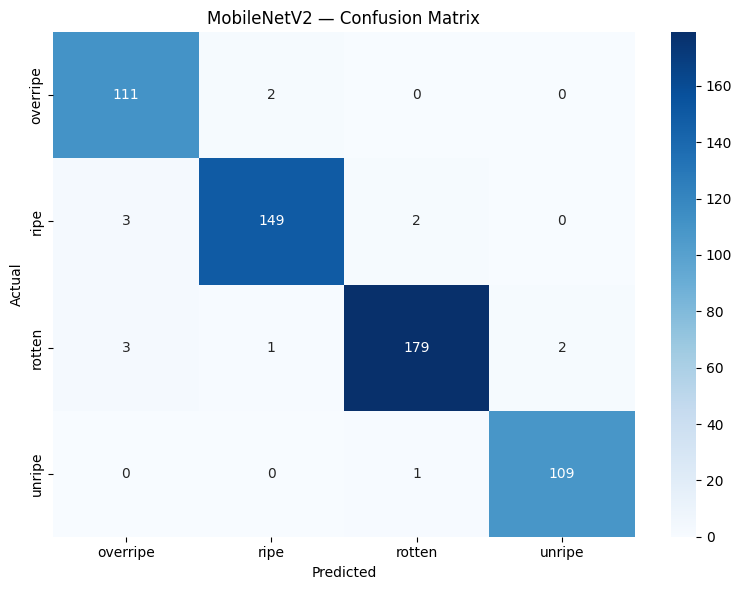

 MobileNetV2 confusion matrix saved!


In [9]:
# Train MobileNetV2

print("=" * 50)
print("1️⃣  MobileNetV2")
print("=" * 50)

train_g_mn, val_g_mn, test_g_mn = make_generators(mobilenet_preprocess)

mobilenet_base = MobileNetV2(
    weights='imagenet', include_top=False, input_shape=(224, 224, 3)
)
mobilenet_model = build_model(mobilenet_base, "MobileNetV2")
mobilenet_model, hist_mn, _ = train_model(
    mobilenet_model, "mobilenetv2", train_g_mn, val_g_mn
)
mobilenet_results = evaluate_model(mobilenet_model, "MobileNetV2", test_g_mn)

2️⃣  EfficientNetB0
Found 11793 images belonging to 4 classes.
Found 1123 images belonging to 4 classes.
Found 562 images belonging to 4 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
 EfficientNetB0 built!
   Total params     : 4,416,039
   Trainable params : 363,908

 Training efficientnetb0...
Epoch 1/20
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.8115 - loss: 0.5223
Epoch 1: val_accuracy improved from None to 0.97507, saving model to /content/drive/MyDrive/advanced_banana_quality_project/models/efficientnetb0_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/advanced_banana_quality_project/models/efficientnetb0_model.keras
369/369 ━━━━━━━━━━━━━━━━━━━━ 241s 574ms/step - accuracy: 0.8788 - loss: 0.3341 - val_accuracy: 0.9751 - val_loss: 0.0862 - learning_rate: 0.0010
Epoch 2/20
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 0.9286 - loss: 0.2030
Epoch 2: val_accuracy did not improve from 0.97507
369/369 ━━━━━━━━━━━━━━━━━━━━ 175s 4

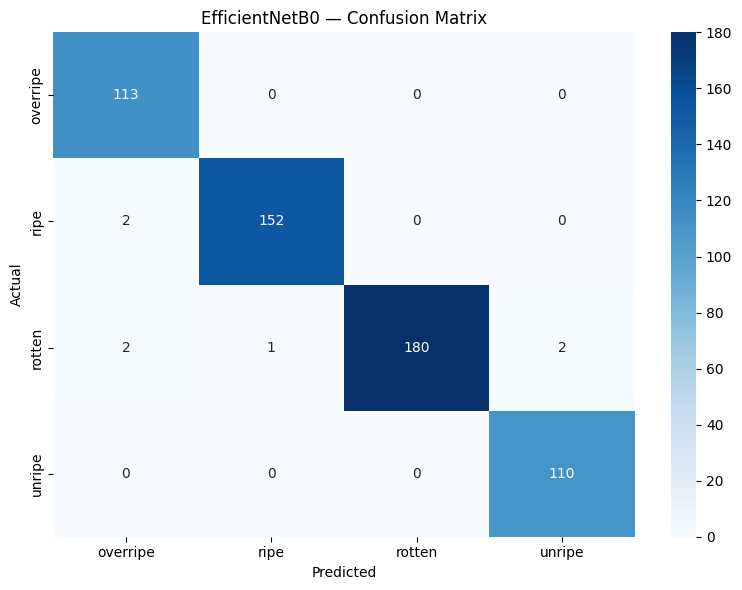

 EfficientNetB0 confusion matrix saved!


In [10]:
# Train EfficientNetB0

print("=" * 50)
print("2️⃣  EfficientNetB0")
print("=" * 50)

train_g_eff, val_g_eff, test_g_eff = make_generators(efficientnet_preprocess)

efficientnet_base = EfficientNetB0(
    weights='imagenet', include_top=False, input_shape=(224, 224, 3)
)
efficientnet_model = build_model(efficientnet_base, "EfficientNetB0")
efficientnet_model, hist_eff, _ = train_model(
    efficientnet_model, "efficientnetb0", train_g_eff, val_g_eff
)
efficientnet_results = evaluate_model(efficientnet_model, "EfficientNetB0", test_g_eff)

3️⃣  ResNet50
Found 11793 images belonging to 4 classes.
Found 1123 images belonging to 4 classes.
Found 562 images belonging to 4 classes.
 ResNet50 built!
   Total params     : 24,153,860
   Trainable params : 562,052

 Training resnet50...
Epoch 1/20
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 563ms/step - accuracy: 0.8406 - loss: 0.4761
Epoch 1: val_accuracy improved from None to 0.96349, saving model to /content/drive/MyDrive/advanced_banana_quality_project/models/resnet50_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/advanced_banana_quality_project/models/resnet50_model.keras
369/369 ━━━━━━━━━━━━━━━━━━━━ 247s 631ms/step - accuracy: 0.8915 - loss: 0.3285 - val_accuracy: 0.9635 - val_loss: 0.1397 - learning_rate: 0.0010
Epoch 2/20
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 530ms/step - accuracy: 0.9324 - loss: 0.1843
Epoch 2: val_accuracy did not improve from 0.96349
369/369 ━━━━━━━━━━━━━━━━━━━━ 199s 540ms/step - accuracy: 0.9382 - loss: 0.1717 - val_accuracy: 0.9466 - val_loss: 0

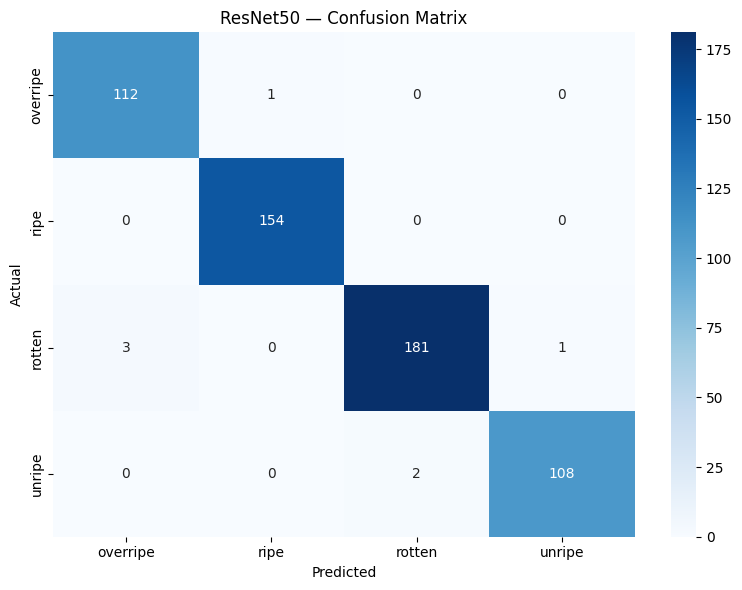

 ResNet50 confusion matrix saved!


In [12]:
# Train ResNet50

print("=" * 50)
print("3️⃣  ResNet50")
print("=" * 50)

train_g_res, val_g_res, test_g_res = make_generators(resnet_preprocess)

resnet_base = ResNet50(
    weights='imagenet', include_top=False, input_shape=(224, 224, 3)
)
resnet_model = build_model(resnet_base, "ResNet50")
resnet_model, hist_res, _ = train_model(
    resnet_model, "resnet50", train_g_res, val_g_res
)
resnet_results = evaluate_model(resnet_model, "ResNet50", test_g_res)

 Model Comparison Table:
         model  test_accuracy  test_loss inference_time_ms  precision  recall  f1_score
      ResNet50          98.75     0.0605              20.8     0.9876  0.9875    0.9875
EfficientNetB0          98.75     0.0370             44.53     0.9878  0.9875    0.9876
   MobileNetV2          97.51     0.0915              37.4     0.9753  0.9751    0.9751
    Custom CNN          97.51     0.0871               N/A     0.9800  0.9800    0.9800

 Saved to reports/model_comparison.csv!


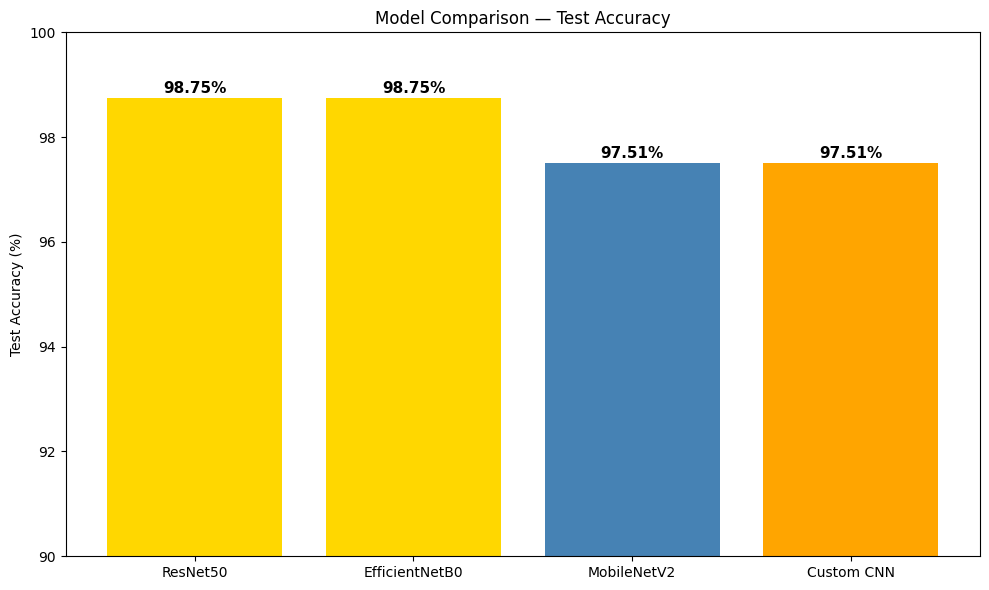

 Comparison chart saved!


In [13]:
# Final Comparison Table + Chart

# Load Custom CNN results
with open(f'{base}/reports/custom_cnn_results.json', 'r') as f:
    cnn_data = json.load(f)

custom_cnn_results = {
    'model': 'Custom CNN',
    'test_accuracy': cnn_data['test_accuracy'],
    'test_loss': cnn_data['test_loss'],
    'inference_time_ms': 'N/A',
    'precision': 0.98,
    'recall': 0.98,
    'f1_score': 0.98
}

all_results = [
    custom_cnn_results,
    mobilenet_results,
    efficientnet_results,
    resnet_results
]

df = pd.DataFrame(all_results)
df = df.sort_values('test_accuracy', ascending=False).reset_index(drop=True)
df.to_csv(f'{base}/reports/model_comparison.csv', index=False)

print(" Model Comparison Table:")
print(df.to_string(index=False))
print("\n Saved to reports/model_comparison.csv!")

# Bar Chart
models     = df['model'].tolist()
accuracies = df['test_accuracy'].tolist()
colors     = ['gold', 'gold', 'steelblue', 'orange']

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=colors[:len(models)])
plt.ylim(90, 100)
plt.ylabel('Test Accuracy (%)')
plt.title('Model Comparison — Test Accuracy')

for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        f'{acc}%', ha='center', fontsize=11, fontweight='bold'
    )

plt.tight_layout()
plt.savefig(f'{base}/screenshots/model_comparison_chart.png')
plt.show()
print(" Comparison chart saved!")